In [3]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"


from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle, select_rows
from BCI_Library import sort_rank, compute_welch_select_regions, extract_features_from_spectra_more_bands,compute_welch
from BCI_Library import plot_hist2d_selected_regions_folds, train_single_model, select_regions_MyCriteria, select_regions_Cohen_effect_size
from BCI_Library import global_selection

"""# new_row = {
#     "ROIs": [selected_regions_EEG],
#     "NROIs":[25]
#     "DataType": ["EEG"],
#     "freqs_band": [((4,8),(8,12),(12,30))],  
#     "subject": [subject_index],
#     "Classifier": ["LDA"],
#     "Performance": [training[0]],
#     "Features": ["PowerSpectra - MeanMax band"],
#     "Comments": ["-"],
#     "Date": [today],
#     "Personalized_Freq_Range" = False,
# }"""


'# new_row = {\n#     "ROIs": [selected_regions_EEG],\n#     "NROIs":[25]\n#     "DataType": ["EEG"],\n#     "freqs_band": [((4,8),(8,12),(12,30))],  \n#     "subject": [subject_index],\n#     "Classifier": ["LDA"],\n#     "Performance": [training[0]],\n#     "Features": ["PowerSpectra - MeanMax band"],\n#     "Comments": ["-"],\n#     "Date": [today],\n#     "Personalized_Freq_Range" = False,\n# }'

# First trainings - old selecitions (no selecting region on kfolds, considering too many bands, etcc)

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

today = date.today()
sfreq = 250


Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": []
})

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances.pkl"
DataType="EEG"
miff = [4,8,12]
maff = [8,12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Classifier_name = "RandomForest" #SVC, #RandomForest, #LDA
meth = RandomForestClassifier
Features_name = "PowerSpectra - MeanMax band"
Comments= "-" # "-"
PFR = False


for subject_index in range(20):
    for num_best_ROIs in range(14,69,3):
        print(f"\n\n Subject {subject_index}")
        data_2_MI = read_subject(data_folder, DataType, "MI",subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline",subject_index, verbose=False)
        #####################################################################################################################
        fmin=3
        fmax=30
        n_per_seg = 250             # window to do power spectra
        n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
        n_overlap = n_per_seg//2

        stime = 1 * sfreq
        etime = 1 * sfreq

        kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
                "n_per_seg":n_per_seg, "n_fft":n_fft,
                "n_overlap":n_overlap}

        #  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
        Feat_extraction = extract_features_more_bands(data_2_MI, data_2_Rest, 
                                        sfreq, starttime=stime, endtime=etime,
                                        min_freq_frature=miff, max_freq_frature=maff, 
                                        nbest_regions=num_best_ROIs, kargs_welch=kargs)

        Feat_MI, Feat_Rest, labls_MI, labls_Rest, selected_regions = Feat_extraction
        Feat_MI.shape
        #####################################################################################################################

        training = train_models(np.concatenate((Feat_MI,Feat_Rest)),np.concatenate((labls_MI,labls_Rest)),
                                method=meth, 
                                seed=224)
        new_row = {
            "ROIs": [selected_regions],
            "NROIs":[len(selected_regions)],
            "DataType": [DataType],
            "freqs_band": [freqs_band],  
            "subject": [subject_index],
            "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
            "Performance": [training[0]],
            "Features": [Features_name],
            "Comments": [Comments],
            "Date": [today],
            "Personalized_Freq_Range": [PFR],
            
        }
        Rows=pd.concat((Rows,pd.DataFrame(new_row)))


if saveresults:
    saveresults_pickle(Rows, inputfile=filepath, outputfile=filepath, backup=True)



 Subject 0
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
###################################################################### 
 Exception occurred: [Errno 2] No such file or directory: '/Users/giovanni.messuti/Desktop/BCI_Project/Results/BUTTARE.pkl' 
 ######################################################################
Cannot Read a previous file, creating a new one at /Users/giovanni.messuti/Desktop/BCI_Project/Results/BUTTARE.pkl


In [ ]:
# Integrate EEG MEG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

today = date.today()
sfreq = 250


Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": []
})

# keys of the performance dictionary
DataType="EEG concat MEG"
saveresults = True
filepath = "../Results/BCI_Performances.pkl"
inputfile=filepath; outputfile=filepath
miff = [4,8,12]
maff = [8,12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Classifier_name = "RandomForest" #SVC, #RandomForest, #LDA
meth = RandomForestClassifier
Features_name = "PowerSpectra - MeanMax band"
Comments= "No Interesting Regions" # "-"
PFR = False


for subject_index in range(20):
    data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
    data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
    data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
    data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)
    
    # miff = freq_personalized[f"subject_{subject_index}"][0]
    # maff = freq_personalized[f"subject_{subject_index}"][-1]
    # freqs_band = (miff, maff)

    for num_best_ROIs in range(8,69,4):
        print(f"\n\n Subject {subject_index}")
        #####################################################################################################################
        fmin=3
        fmax=30
        n_per_seg = 250             # window to do power spectra
        n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
        n_overlap = n_per_seg//2

        stime = 1 * sfreq
        etime = 1 * sfreq

        kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
                "n_per_seg":n_per_seg, "n_fft":n_fft,
                "n_overlap":n_overlap}

        #  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
        Feat_extraction_EEG = extract_features_more_bands(data_2_MI_EEG, data_2_Rest_EEG, 
                                        sfreq, starttime=stime, endtime=etime,
                                        min_freq_frature=miff, max_freq_frature=maff, 
                                        nbest_regions=num_best_ROIs, kargs_welch=kargs,
                                        important_regions=[],
                                        )

        Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG
    
        Feat_extraction_MEG = extract_features_more_bands(data_2_MI_MEG, data_2_Rest_MEG, 
                                        sfreq, starttime=stime, endtime=etime,
                                        min_freq_frature=miff, max_freq_frature=maff, 
                                        nbest_regions=num_best_ROIs, kargs_welch=kargs,
                                        important_regions=[],
                                        )

        Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

        Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_MEG), axis=1)
        Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_MEG), axis=1)
        Features = np.concatenate((Features_MI,Features_Rest))
        Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
        #print(Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape)
        #####################################################################################################################

        training = train_models(Features,Labels,
                                method=meth, 
                                seed=224,
                                verbose=True)
        new_row = {
            "ROIs": [[selected_regions_EEG]+[selected_regions_MEG]],
            "NROIs":[len(selected_regions_EEG)],
            "DataType": [DataType],
            "freqs_band": [freqs_band],  
            "subject": [subject_index],
            "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
            "Performance": [training[0]],
            "Features": [Features_name],
            "Comments": [Comments],
            "Date": [today],
            "Personalized_Freq_Range": [PFR],
            
        }
        Rows=pd.concat((Rows,pd.DataFrame(new_row)))



if saveresults:
    saveresults_pickle(Rows, inputfile=filepath, outputfile=filepath, backup=True)



 Subject 0
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)

----- Fold 1 -----
Fold 1 accuracy: 0.9688, Confusion matrix:
[[19  0]
 [ 1 12]]

----- Fold 2 -----
Fold 2 accuracy: 1.0000, Confusion matrix:
[[17  0]
 [ 0 14]]

----- Fold 3 -----
Fold 3 accuracy: 0.9677, Confusion matrix:
[[12  1]
 [ 0 18]]

----- Fold 4 -----
Fold 4 accuracy: 0.9355, Confusion matrix:
[[15  0]
 [ 2 14]]

----- Fold 5 -----
Fold 5 accuracy: 0.9677, Confusion matrix:
[[13  1]
 [ 0 17]]

Mean accuracy: 0.9679435483870968
Std accuracy: 0.020405775691741946


 Subject 0
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)

----- Fold 1 -----
Fold 1 accuracy: 1.0000, Confusion matrix:
[[19  0]
 [ 0 13]]

----- Fold 2 -----
Fold 2 accuracy: 1.0000, Confusion matrix:
[[17  0]
 [ 0 14]]

----- Fold 3 -----
Fold 3 accuracy: 0.9677, Confusion mat

# Trainings from 15/12/2025 


Selection of regions in Kfolds, different selections criteria, consider only alpha beta bands

## stratified k fold - 5 folds

### MyCriteria

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm

today = date.today()
sfreq = 250

seed = 224

saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "MyCriteria selection" # "-"
PFR = False

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip([ "LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)

            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI))]-len(WMI)

                    regions_selected = select_regions_MyCriteria(wpsdMI=WMI[training_index_MI], 
                                                                    wpsdRest=WRe[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################

                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG LDA


100%|██████████| 20/20 [01:40<00:00,  5.00s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG SVC


100%|██████████| 20/20 [01:23<00:00,  4.19s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG SVC


100%|██████████| 20/20 [01:24<00:00,  4.24s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest


100%|██████████| 20/20 [02:30<00:00,  7.51s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [ ]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "MyCriteria selection" # "-"
PFR = False

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG concat MEG"]:
    for Classifier_name, meth in zip(["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
            data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
            data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

            WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
            Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)

            Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
            Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
            labels_All_EEG= labels_EEG

            #################################################################################

            WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
            Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)
            Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
            Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
            labels_All_MEG= np.array(labels_MEG)


            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI_EEG))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI_EEG))]-len(WMI_EEG)

                    regions_selected_EEG = select_regions_MyCriteria(wpsdMI=WMI_EEG[training_index_MI], 
                                                                    wpsdRest=WRe_EEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)
                    
                    regions_selected_MEG = select_regions_MyCriteria(wpsdMI=WMI_MEG[training_index_MI], 
                                                                    wpsdRest=WRe_MEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, labels_All_MEG,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG concat MEG LDA


100%|██████████| 20/20 [02:49<00:00,  8.48s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG SVC


100%|██████████| 20/20 [02:36<00:00,  7.82s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG RandomForest


100%|██████████| 20/20 [03:44<00:00, 11.23s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


### T Test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm
import pingouin as pg


seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "T test selection mean power alpha beta" # "-"
PFR = False
Classifier_name = "RandomForest" #SVC, #RandomForest, #LDA
meth = RandomForestClassifier


n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):
    
        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            mean_alph = np.concatenate((WMI[:,:,np.where(FreqMI<12)].mean(axis=-1),WMI[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)
            mean_beta = np.concatenate((WRe[:,:,np.where(FreqMI<12)].mean(axis=-1),WRe[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
                
            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = labels

            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):

                    pvalues = []
                    for region in range(68):
                        result = pg.multivariate_ttest(mean_alph[train_idx[np.where(train_idx<len(mean_alph))],region,:], 
                                                    mean_beta[train_idx[np.where(train_idx>=len(mean_alph))]-len(mean_alph),region,:])
                        pvalues.append(float(result.pval.values[0]))
                    pvalues=np.array(pvalues)
                    regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
                    regions_selected = regions_selected[:num_best_ROIs]
                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################
                    
                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)
                        
                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_output, outputfile=file_output, backup=True)



##############################
 EEG SVC


100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest


100%|██████████| 20/20 [00:32<00:00,  1.64s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG LDA


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest


100%|██████████| 20/20 [00:32<00:00,  1.64s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG LDA


100%|██████████| 20/20 [00:27<00:00,  1.36s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [ ]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import pingouin as pg

seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "T test selection mean power alpha beta" # "-"
PFR = False

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG concat MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
            data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
            data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

            WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
            Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)

            Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
            Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
            labels_All_EEG= labels_EEG

            #################################################################################

            WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
            Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)
            Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
            Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
            labels_All_MEG= labels_MEG

            mean_alph_EEG = np.concatenate((WMI_EEG[:,:,np.where(FreqMI_EEG<12)].mean(axis=-1),WMI_EEG[:,:,np.where(FreqMI_EEG>=12)].mean(axis=-1)),axis=-1)
            mean_beta_EEG = np.concatenate((WRe_EEG[:,:,np.where(FreqMI_EEG<12)].mean(axis=-1),WRe_EEG[:,:,np.where(FreqMI_EEG>=12)].mean(axis=-1)),axis=-1)

            mean_alph_MEG = np.concatenate((WMI_MEG[:,:,np.where(FreqMI_MEG<12)].mean(axis=-1),WMI_MEG[:,:,np.where(FreqMI_MEG>=12)].mean(axis=-1)),axis=-1)
            mean_beta_MEG = np.concatenate((WRe_MEG[:,:,np.where(FreqMI_MEG<12)].mean(axis=-1),WRe_MEG[:,:,np.where(FreqMI_MEG>=12)].mean(axis=-1)),axis=-1)

            for num_best_ROIs in [3,5,10,20, 40]:

                fold_accuracies = []
                fold_confusions = []
                trained_models = []
                val_indexes = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):

                    # selecting region based on training data only
                    pvalues_EEG = []
                    for region in range(68):
                        result_EEG = pg.multivariate_ttest(mean_alph_EEG[train_idx[np.where(train_idx<len(mean_alph_EEG))],region,:], 
                                                    mean_beta_EEG[train_idx[np.where(train_idx>=len(mean_alph_EEG))]-len(mean_alph_EEG),region,:])
                        pvalues_EEG.append(float(result_EEG.pval.values[0]))
                    pvalues_EEG=np.array(pvalues_EEG)
                    regions_selected_EEG=pvalues_EEG.argsort() # in base a chi ha il pvalue più piccolo
                    regions_selected_EEG = regions_selected_EEG[:num_best_ROIs]

                    pvalues_MEG = []
                    for region in range(68):
                        result_MEG = pg.multivariate_ttest(mean_alph_MEG[train_idx[np.where(train_idx<len(mean_alph_MEG))],region,:], 
                                                    mean_beta_MEG[train_idx[np.where(train_idx>=len(mean_alph_MEG))]-len(mean_alph_MEG),region,:])
                        pvalues_MEG.append(float(result_MEG.pval.values[0]))
                    pvalues_MEG=np.array(pvalues_MEG)
                    regions_selected_MEG=pvalues_MEG.argsort() # in base a chi ha il pvalue più piccolo
                    regions_selected_MEG = regions_selected_MEG[:num_best_ROIs]

                    
                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################

                    X_train, X_val = Feat_All_regions_selected_concat[train_idx], Feat_All_regions_selected_concat[val_idx]
                    y_train, y_val = np.array(labels_All_MEG)[train_idx], np.array(labels_All_MEG)[val_idx]
                    val_indexes.append(val_idx)

                    # StandardScaler:
                    scaler_instance = StandardScaler()
                    X_train_scaled = scaler_instance.fit_transform(X_train)
                    X_val_scaled   = scaler_instance.transform(X_val)

                    # Model instance
                    try:
                        model = meth(random_state=seed)
                    except:
                        model = meth()
                    model.fit(X_train_scaled, y_train)
                    trained_models.append(model)

                    # Predict on validation
                    y_pred = model.predict(X_val_scaled)

                    # Accuracy
                    acc = accuracy_score(y_val, y_pred)
                    fold_accuracies.append(acc)

                    # Confusion matrix
                    cm = confusion_matrix(y_val, y_pred)
                    fold_confusions.append(cm)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG concat MEG SVC


100%|██████████| 20/20 [00:55<00:00,  2.76s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG RandomForest


100%|██████████| 20/20 [01:01<00:00,  3.05s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG LDA


100%|██████████| 20/20 [00:55<00:00,  2.76s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


### Cohen's d effect size

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm

today = date.today()
sfreq = 250

seed = 224

saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "Cohen's d effect size selection" # "-"
PFR = False



n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)

            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI))]-len(WMI)

                    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                                    wpsdRest=WRe[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################

                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG SVC


100%|██████████| 20/20 [00:26<00:00,  1.34s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest


100%|██████████| 20/20 [00:47<00:00,  2.36s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG LDA


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest


100%|██████████| 20/20 [00:47<00:00,  2.35s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG LDA


100%|██████████| 20/20 [00:25<00:00,  1.28s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [ ]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "Cohen's d effect size selection" # "Cohen's d effect size selection spectra starting from 3s"
PFR = False

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG concat MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
            data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
            data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

            WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
            Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)

            Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
            Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
            labels_All_EEG= labels_EEG

            #################################################################################

            WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
            Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)
            Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
            Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
            labels_All_MEG= labels_MEG


            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI_EEG))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI_EEG))]-len(WMI_EEG)

                    regions_selected_EEG, effect_size = select_regions_Cohen_effect_size(wpsdMI=WMI_EEG[training_index_MI], 
                                                                    wpsdRest=WRe_EEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)
                    
                    regions_selected_MEG, effect_size = select_regions_Cohen_effect_size(wpsdMI=WMI_MEG[training_index_MI], 
                                                                    wpsdRest=WRe_MEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, np.array(labels_All_MEG),
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG concat MEG SVC


100%|██████████| 20/20 [00:50<00:00,  2.51s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG RandomForest


100%|██████████| 20/20 [01:14<00:00,  3.75s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG LDA


100%|██████████| 20/20 [00:52<00:00,  2.60s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


### Global Region Selection

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm

today = date.today()
sfreq = 250
seed = 224

global_selection_base = "MyCriteria" #"Cohen", "MyCriteria"
selection_method = "MyCriteria" if global_selection_base=="MyCriteria" else "Cohen_effect_size" if global_selection_base=="Cohen" else None


saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= f"Global Selection - {global_selection_base} based" # "-"
PFR = False


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name, global_selection_base)

        regions_selected  = global_selection(selection_method, DataType)
        print(regions_selected)

        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)


            fold_accuracies = []

            for fold_idx, (train_idx, val_idx) in enumerate(skf.split([0 for _ in range(len(labels))], labels)):


                Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                #####################################################################################################################

                acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                    train_idx, val_idx, method=meth, seed=224)

                fold_accuracies.append(acc)
                if verbose:
                    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                    print(cm)

                #####################################################################################################################

            if verbose:
                print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                print("Std accuracy:", np.std(fold_accuracies))

            new_row = {
                "ROIs": [regions_selected],
                "NROIs":[len(regions_selected)],
                "DataType": [DataType],
                "freqs_band": [freqs_band],  
                "subject": [subject_index],
                "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                "Performance": [fold_accuracies],
                "Features": [Features_name],
                "Comments": [Comments],
                "Date": [today],
                "Personalized_Freq_Range": [PFR],
            }
            Rows=pd.concat((Rows,pd.DataFrame(new_row)))
    

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

In [ ]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm

seed = 224

for global_selection_base in ["MyCriteria", "Cohen"]:
    selection_method = "MyCriteria" if global_selection_base=="MyCriteria" else "Cohen_effect_size" if global_selection_base=="Cohen" else None

    saveresults = True
    filepath = "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
    file_input = filepath
    file_output = filepath
    miff = [8,12]
    maff = [12,30]
    freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
    Features_name = "PowerSpectra - MeanMax band"
    Comments= f"Global Selection - {global_selection_base} based" # "-"
    PFR = False

    n_folds=5
    skf = StratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
    today = date.today()
    sfreq = 250

    tutte_roi = 68
    verbose = False


    regions_selected_EEG  = global_selection(selection_method, "EEG")
    regions_selected_MEG =  global_selection(selection_method, "MEG")
    print("selected EEG", regions_selected_EEG) 
    print("selected MEG", regions_selected_MEG) 


    for DataType in ["EEG concat MEG"]:
        for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

            Rows = pd.DataFrame({
                "ROIs": [],
                "NROIs":[],
                "DataType": [],
                "freqs_band": [],  
                "subject": [],
                "Classifier": [],
                "Performance": [],
                "Features": [],
                "Comments": [],
                "Date": []
            })
            print("\n\n"+"#"*30+"\n",global_selection_base,DataType,Classifier_name)
            for subject_index in tqdm.tqdm(range(20)):

                data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
                data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
                data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
                data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

                WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                                kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
                # WMI.shape (trials, ROIs, freqs)
                labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
                Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                        min_freq_frature=miff, max_freq_frature=maff, 
                        select_mean=True, select_max=True,
                        reshape_features=False)

                Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
                # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
                Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
                labels_All_EEG= labels_EEG

                #################################################################################

                WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                                kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
                labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
                Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                        min_freq_frature=miff, max_freq_frature=maff, 
                        select_mean=True, select_max=True,
                        reshape_features=False)
                Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
                Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
                labels_All_MEG= labels_MEG




                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(skf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):
                    

                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, np.array(labels_All_MEG),
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
            


            if saveresults:
                saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

## Repeated Stratified k fold - 10 folds

### Visualization of selection

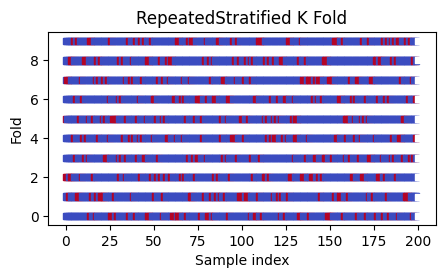

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=224)
skf = StratifiedKFold(n_splits=5)

X = np.zeros((200, 3)); y = np.array([0]*100 + [1]*100)
plt.figure(figsize=(5,2.5))
for i, (tr, te) in enumerate(skf.split(X, y)):
    row = np.full(len(X), np.nan)
    row[tr] = 0;  row[te] = 1
    plt.scatter(range(len(X)), [i]*len(X), c=row, cmap="coolwarm", s=20, marker="s",edgecolors=None)
    plt.scatter([200], [i], color="white", s=20, marker="s",edgecolors="white")
plt.xlabel("Sample index"); plt.ylabel("Fold"); plt.title("RepeatedStratified K Fold"); plt.show()

### MyCriteria

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm

today = date.today()
sfreq = 250

seed = 224

saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "MyCriteria selection" # "-"
PFR = False

n_folds=5
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip([ "LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)

            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels))], labels)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI))]-len(WMI)

                    regions_selected = select_regions_MyCriteria(wpsdMI=WMI[training_index_MI], 
                                                                    wpsdRest=WRe[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################

                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG LDA


100%|██████████| 20/20 [01:24<00:00,  4.21s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG SVC


100%|██████████| 20/20 [01:22<00:00,  4.11s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG SVC


100%|██████████| 20/20 [01:22<00:00,  4.12s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest


100%|██████████| 20/20 [03:24<00:00, 10.24s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [4]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm


seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "MyCriteria selection" # "-"
PFR = False

n_folds=5
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG concat MEG"]:
    for Classifier_name, meth in zip(["LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
            data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
            data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

            WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
            Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)

            Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
            Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
            labels_All_EEG= labels_EEG

            #################################################################################

            WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
            Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)
            Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
            Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
            labels_All_MEG= np.array(labels_MEG)


            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI_EEG))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI_EEG))]-len(WMI_EEG)

                    regions_selected_EEG = select_regions_MyCriteria(wpsdMI=WMI_EEG[training_index_MI], 
                                                                    wpsdRest=WRe_EEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)
                    
                    regions_selected_MEG = select_regions_MyCriteria(wpsdMI=WMI_MEG[training_index_MI], 
                                                                    wpsdRest=WRe_MEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, labels_All_MEG,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG concat MEG LDA


100%|██████████| 20/20 [02:54<00:00,  8.73s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG SVC


100%|██████████| 20/20 [03:07<00:00,  9.39s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG RandomForest


100%|██████████| 20/20 [04:49<00:00, 14.48s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


### Choen's d effect size

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm

today = date.today()
sfreq = 250

seed = 224

saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "Cohen's d effect size selection" # "-"
PFR = False



n_folds=5
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)

            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels))], labels)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI))]-len(WMI)

                    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                                    wpsdRest=WRe[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################

                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG SVC


100%|██████████| 20/20 [01:24<00:00,  4.25s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest


100%|██████████| 20/20 [03:22<00:00, 10.11s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG LDA


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest


100%|██████████| 20/20 [03:23<00:00, 10.20s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG LDA


100%|██████████| 20/20 [01:27<00:00,  4.36s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [6]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm

seed = 224

# keys of the performance dictionary
saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "Cohen's d effect size selection" # "Cohen's d effect size selection spectra starting from 3s"
PFR = False

n_folds=5
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG concat MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
            data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
            data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
            data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

            WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)
            labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
            Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)

            Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
            Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
            labels_All_EEG= labels_EEG

            #################################################################################

            WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
            Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)
            Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
            Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
            labels_All_MEG= labels_MEG


            for num_best_ROIs in [3,5,10,20,40]:

                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):

                    # selecting region based on training data only
                    training_index_MI = train_idx[np.where(train_idx<len(WMI_EEG))]
                    training_index_Re = train_idx[np.where(train_idx>=len(WMI_EEG))]-len(WMI_EEG)

                    regions_selected_EEG, effect_size = select_regions_Cohen_effect_size(wpsdMI=WMI_EEG[training_index_MI], 
                                                                    wpsdRest=WRe_EEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)
                    
                    regions_selected_MEG, effect_size = select_regions_Cohen_effect_size(wpsdMI=WMI_MEG[training_index_MI], 
                                                                    wpsdRest=WRe_MEG[training_index_MI], 
                                                                    important_regions=[], nbest_regions=num_best_ROIs)

                    
                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, np.array(labels_All_MEG),
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        


        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG concat MEG SVC


100%|██████████| 20/20 [02:46<00:00,  8.35s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG RandomForest


100%|██████████| 20/20 [04:50<00:00, 14.52s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG concat MEG LDA


100%|██████████| 20/20 [02:51<00:00,  8.57s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


### Global Region Selection

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm

today = date.today()
sfreq = 250
seed = 224

global_selection_base = "MyCriteria" #"Cohen", "MyCriteria"
selection_method = "MyCriteria" if global_selection_base=="MyCriteria" else "Cohen_effect_size" if global_selection_base=="Cohen" else None


saveresults = True
filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= f"Global Selection - {global_selection_base} based" # "-"
PFR = False


rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name, global_selection_base)

        regions_selected  = global_selection(selection_method, DataType)
        print(regions_selected)

        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)


            fold_accuracies = []

            for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels))], labels)):


                Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                #####################################################################################################################

                acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                    train_idx, val_idx, method=meth, seed=224)

                fold_accuracies.append(acc)
                if verbose:
                    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                    print(cm)

                #####################################################################################################################

            if verbose:
                print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                print("Std accuracy:", np.std(fold_accuracies))

            new_row = {
                "ROIs": [regions_selected],
                "NROIs":[len(regions_selected)],
                "DataType": [DataType],
                "freqs_band": [freqs_band],  
                "subject": [subject_index],
                "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                "Performance": [fold_accuracies],
                "Features": [Features_name],
                "Comments": [Comments],
                "Date": [today],
                "Personalized_Freq_Range": [PFR],
            }
            Rows=pd.concat((Rows,pd.DataFrame(new_row)))
    

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)



##############################
 EEG SVC MyCriteria
[6, 7, 14, 22, 23, 32, 48, 50, 59]


100%|██████████| 20/20 [01:15<00:00,  3.78s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG RandomForest MyCriteria
[6, 7, 14, 22, 23, 32, 48, 50, 59]


100%|██████████| 20/20 [01:36<00:00,  4.83s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 EEG LDA MyCriteria
[6, 7, 14, 22, 23, 32, 48, 50, 59]


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG RandomForest MyCriteria
[6, 7, 14, 22, 23, 32, 42, 43, 44, 48, 51]


100%|██████████| 20/20 [01:37<00:00,  4.87s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MEG LDA MyCriteria
[6, 7, 14, 22, 23, 32, 42, 43, 44, 48, 51]


100%|██████████| 20/20 [01:14<00:00,  3.75s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


In [2]:
#Integrate EEG EMG
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import RepeatedStratifiedKFold
import tqdm

seed = 224

for global_selection_base in ["MyCriteria", "Cohen"]:
    selection_method = "MyCriteria" if global_selection_base=="MyCriteria" else "Cohen_effect_size" if global_selection_base=="Cohen" else None

    saveresults = True
    filepath = "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
    file_input = filepath
    file_output = filepath
    miff = [8,12]
    maff = [12,30]
    freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
    Features_name = "PowerSpectra - MeanMax band"
    Comments= f"Global Selection - {global_selection_base} based" # "-"
    PFR = False

    n_folds=5
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=seed)
    today = date.today()
    sfreq = 250

    tutte_roi = 68
    verbose = False


    regions_selected_EEG  = global_selection(selection_method, "EEG")
    regions_selected_MEG =  global_selection(selection_method, "MEG")
    print("selected EEG", regions_selected_EEG) 
    print("selected MEG", regions_selected_MEG) 


    for DataType in ["EEG concat MEG"]:
        for Classifier_name, meth in zip(["SVC", "RandomForest", "LDA"],[SVC, RandomForestClassifier, LDA]):

            Rows = pd.DataFrame({
                "ROIs": [],
                "NROIs":[],
                "DataType": [],
                "freqs_band": [],  
                "subject": [],
                "Classifier": [],
                "Performance": [],
                "Features": [],
                "Comments": [],
                "Date": []
            })
            print("\n\n"+"#"*30+"\n",global_selection_base,DataType,Classifier_name)
            for subject_index in tqdm.tqdm(range(20)):

                data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
                data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
                data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
                data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)

                WMI_EEG, WRe_EEG, FreqMI_EEG = compute_welch(data_2_MI_EEG, data_2_Rest_EEG, sfreq,
                                                                kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
                # WMI.shape (trials, ROIs, freqs)
                labels_EEG = [1 for __ in range(len(WMI_EEG))] + [0 for __ in range(len(WRe_EEG))] 
                Feat_extraction_EEG = extract_features_from_spectra_more_bands(WMI_EEG, WRe_EEG, [ _ for _ in range(tutte_roi)], FreqMI_EEG,
                        min_freq_frature=miff, max_freq_frature=maff, 
                        select_mean=True, select_max=True,
                        reshape_features=False)

                Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, all_regions_EEG = Feat_extraction_EEG
                # Feat_MI.shape (Trials, selected_ROIs, features for Roi)
                Feat_All_EEG = np.concatenate((Feat_MI_EEG, Feat_Rest_EEG), axis=0)
                labels_All_EEG= labels_EEG

                #################################################################################

                WMI_MEG, WRe_MEG, FreqMI_MEG = compute_welch(data_2_MI_MEG, data_2_Rest_MEG, sfreq,
                                                                kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
                labels_MEG = [1 for __ in range(len(WMI_MEG))] + [0 for __ in range(len(WRe_MEG))] 
                Feat_extraction_MEG = extract_features_from_spectra_more_bands(WMI_MEG, WRe_MEG, [ _ for _ in range(tutte_roi)], FreqMI_MEG,
                        min_freq_frature=miff, max_freq_frature=maff, 
                        select_mean=True, select_max=True,
                        reshape_features=False)
                Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, all_regions_MEG = Feat_extraction_MEG
                Feat_All_MEG = np.concatenate((Feat_MI_MEG, Feat_Rest_MEG), axis=0)
                labels_All_MEG= labels_MEG




                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(rskf.split([0 for _ in range(len(labels_MEG))], labels_MEG)):
                    

                    Feat_All_regions_selected_EEG = Feat_All_EEG[:,regions_selected_EEG,:].reshape(Feat_All_EEG.shape[0],-1)
                    Feat_All_regions_selected_MEG = Feat_All_MEG[:,regions_selected_MEG,:].reshape(Feat_All_MEG.shape[0],-1)
                    # Feat_All_regions_selected_EEG.shape is (trials,features)
                    Feat_All_regions_selected_concat = np.concatenate((Feat_All_regions_selected_EEG,Feat_All_regions_selected_MEG),axis=-1)
                    #####################################################################################################################
                    acc, cm, model = train_single_model(Feat_All_regions_selected_concat, np.array(labels_All_MEG),
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                # Summary
                if verbose:
                    print("\n==================================")
                    print("Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))



                new_row = {
                    "ROIs": [[regions_selected_EEG,regions_selected_MEG]],
                    "NROIs":[len(regions_selected_EEG)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
            


            if saveresults:
                saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

selected EEG [6, 7, 14, 22, 23, 32, 48, 50, 59]
selected MEG [6, 7, 14, 22, 23, 32, 42, 43, 44, 48, 51]


##############################
 MyCriteria EEG concat MEG SVC


100%|██████████| 20/20 [02:33<00:00,  7.68s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MyCriteria EEG concat MEG RandomForest


100%|██████████| 20/20 [02:52<00:00,  8.65s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 MyCriteria EEG concat MEG LDA


...

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 Cohen EEG concat MEG RandomForest


100%|██████████| 20/20 [02:54<00:00,  8.74s/it]


There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


##############################
 Cohen EEG concat MEG LDA


100%|██████████| 20/20 [02:30<00:00,  7.52s/it]

There are 0 duplicated items (based on all columns except Date, ROIs, Performance).
 Index of the duplicated items: []


# On 1 region

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
import tqdm

today = date.today()
sfreq = 250

seed = 224

saveresults = False
filepath = "../Results/BCI_Performances_on_single_region.pkl"
file_input = filepath
file_output = filepath
miff = [8,12]
maff = [12,30]
freqs_band = tuple([(i,j) for i,j in zip(miff,maff)])
Features_name = "PowerSpectra - MeanMax band"
Comments= "-" # "-"
PFR = False

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

tutte_roi = 68
verbose = False

for DataType in ["EEG","MEG"]:
    for Classifier_name, meth in zip([ "LDA", "SVC", "RandomForest"],[LDA, SVC, RandomForestClassifier]):

        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(range(20)):

            data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
            data_2_Rest = read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)

            WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                                            kargs_welch={"fmin":miff[0], "fmax":maff[-1]})
            # WMI.shape (trials, ROIs, freqs)

            labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 

            Feat_extraction = extract_features_from_spectra_more_bands(WMI, WRe, [ _ for _ in range(tutte_roi)], FreqMI,
                    min_freq_frature=miff, max_freq_frature=maff, 
                    select_mean=True, select_max=True,
                    reshape_features=False)


            Feat_MI, Feat_Rest, labls_MI, labls_Rest, all_regions = Feat_extraction
            #print("\n\n"+"#"*30+"featureMI.shape",Feat_MI.shape)
            # Feat_MI.shape (Trials, selected_ROIs, features for Roi)

            Feat_All = np.concatenate((Feat_MI, Feat_Rest), axis=0)
            #print("\n\n"+"#"*30+"Feat_All.shape",Feat_All.shape)
            labels_All = np.array(labels)


            for region_idx in range(tutte_roi):

                regions_selected = [region_idx]
                fold_accuracies = []

                for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
                    
                    Feat_All_regions_selected = Feat_All[:,regions_selected,:].reshape(Feat_All.shape[0],-1)
                    #print("\n\n"+"#"*30+"Feat_All_regions_selected.shape",Feat_All_regions_selected.shape)
                    #####################################################################################################################

                    acc, cm, model = train_single_model(Feat_All_regions_selected, labels_All,
                                                        train_idx, val_idx, method=meth, seed=224)

                    fold_accuracies.append(acc)
                    if verbose:
                        print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                        print(cm)

                    #####################################################################################################################

                if verbose:
                    print("\n==================================\n","Mean accuracy:", np.mean(fold_accuracies))
                    print("Std accuracy:", np.std(fold_accuracies))

                new_row = {
                    "ROIs": [regions_selected],
                    "NROIs":[len(regions_selected)],
                    "DataType": [DataType],
                    "freqs_band": [freqs_band],  
                    "subject": [subject_index],
                    "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                    "Performance": [fold_accuracies],
                    "Features": [Features_name],
                    "Comments": [Comments],
                    "Date": [today],
                    "Personalized_Freq_Range": [PFR],
                }
                Rows=pd.concat((Rows,pd.DataFrame(new_row)))
        

        if saveresults:
            saveresults_pickle(Rows, inputfile=file_input, outputfile=file_output, backup=True)

In [12]:
regions_selected

[23,
 15,
 14,
 22,
 50,
 58,
 17,
 42,
 51,
 6,
 35,
 59,
 27,
 32,
 7,
 43,
 13,
 34,
 21,
 55,
 16,
 9,
 25,
 29,
 26,
 37,
 48,
 53,
 20,
 45,
 24,
 49,
 66,
 0,
 62,
 10,
 28,
 41,
 11,
 33]

In [1]:
import pandas as pd
Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": []
})


Rows.to_pickle ("../Results/BCI_Performances_on_single_region.pkl")

# Test

In [ ]:
import pandas as pd
Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Performance": [],
            "Features": [],
            "Comments": [],
            "Date": []
        })
# Rows.to_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz_features_on_3_bands.pkl")

In [ ]:
pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
0,"[23, 15, 14]",3.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.875, 0.8709677419354839, 0.9032258064516129...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
1,"[23, 15, 14, 22, 17]",5.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8387096774193549, 0.838709677419354...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
2,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58]",10.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8709677419354839, 0.870967741935483...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
3,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58, 51, 27...",20.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.96875, 0.8709677419354839, 0.90322580645161...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
4,"[67, 61, 43]",3.0,EEG,"((8, 12), (12, 30))",1.0,SVC,"[0.7368421052631579, 0.7368421052631579, 0.710...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
...,...,...,...,...,...,...,...,...,...,...,...
1435,"[[60, 62, 66, 44, 29, 18, 36, 25, 65, 39, 40, ...",20.0,EEG concat MEG,"((8, 12), (12, 30))",18.0,LDA,"[0.5428571428571428, 0.5714285714285714, 0.714...",PowerSpectra - MeanMax band,T test selection mean power alpha beta,2025-12-15,False
1436,"[[51, 21, 63], [44, 32, 47]]",3.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,LDA,"[0.7368421052631579, 0.7105263157894737, 0.868...",PowerSpectra - MeanMax band,T test selection mean power alpha beta,2025-12-15,False
1437,"[[51, 21, 63, 33, 45], [44, 32, 47, 33, 46]]",5.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,LDA,"[0.7894736842105263, 0.7631578947368421, 0.842...",PowerSpectra - MeanMax band,T test selection mean power alpha beta,2025-12-15,False
1438,"[[51, 21, 63, 33, 45, 55, 17, 35, 11, 49], [44...",10.0,EEG concat MEG,"((8, 12), (12, 30))",19.0,LDA,"[0.7368421052631579, 0.6842105263157895, 0.789...",PowerSpectra - MeanMax band,T test selection mean power alpha beta,2025-12-15,False


In [9]:
1440/80

18.0